In [1]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata

/Users/eb35267/Desktop/code/home/escripts/eplots.py:624: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'$z \simeq {z}$')


In [129]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Donnan24_high_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Kokorev+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Weibel+25_upper_limits.txt']
data_labels = ['Bouwens+21', 'Donnan+24', '', 'Kokorev+25', 'Weibel+25']
include = [True, True, False, False, False]
sorted_data = edata.get_sorted(file_names, data_labels, include_in_likelihood = include)

In [178]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [179]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz': {'fit': False, 'value': 0.22}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [169]:
best_fit = [0.51, -0.02, 11.74, -0.04, -1.33, -0.12, 0.52, 0.23, -0.03, 0.67]
no_z_ev = [1.02, -0.02, 11.54, -0.01, -1.45, -0.16, 0.58, 0, -1.1, 0.79]
no_m_ev = [0.49, -0.02, 11.76, -0.04, -1.34, -0.12, 0.53, 0.24, 0, 0.67]
no_ev = [0.39, -0.07, 12.05, 0.08, -1.39, -0.13, 0.75, 0, 0, 0.3]
low_sig = [0.54, 0.02, 12, -0.07, -1.01, -0.05, 0.3, 0, 0, 0.3]

In [ ]:
import zeus21

In [175]:
M_atom = np.array([zeus21.sfrd.Matom(zcenter) for zcenter in my_UVLF.zs])
min_MUV = my_UVLF.calc_min_MUV(M_atom)

# Plot from chain

In [74]:
chain = '/Users/eb35267/Desktop/code/chains/all_params_free/samples.h5'

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:222: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:222: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)


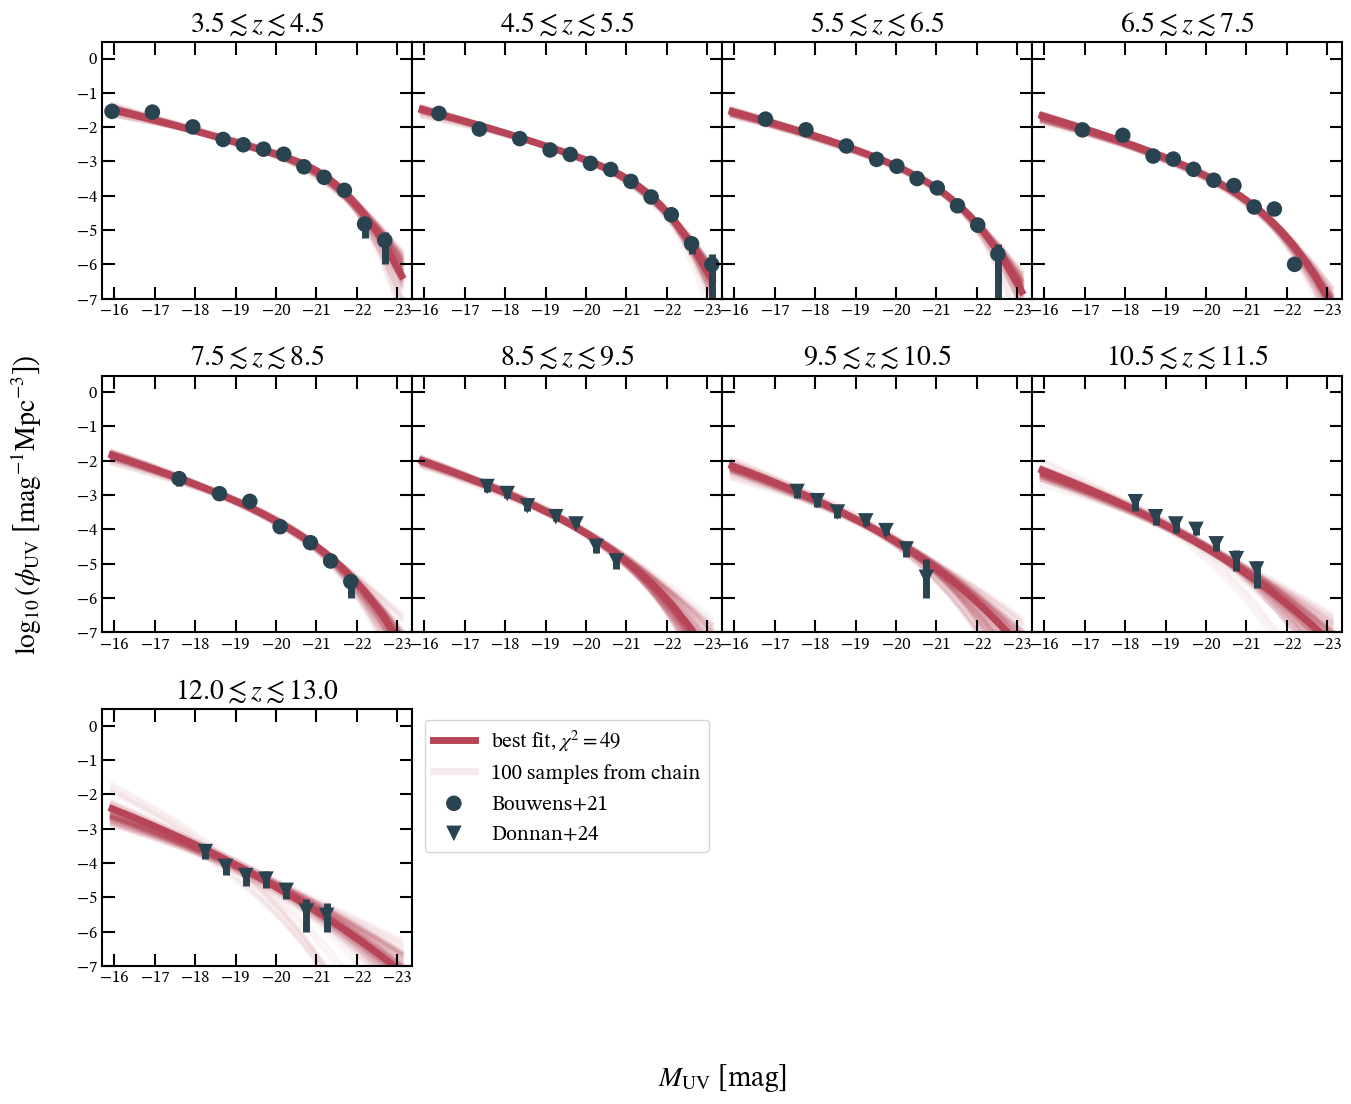

In [180]:
from_chain = eplots.evolving_UVLF_fit(my_UVLF, backend_file = chain, ncols = 4)

In [252]:
from_chain.savefig('/Users/eb35267/Desktop/figures/Qual_26/from_chain.png', dpi = 200)

# Best fit corner

In [96]:
chain = '/Users/eb35267/Desktop/code/chains/all_params_free/samples.h5'

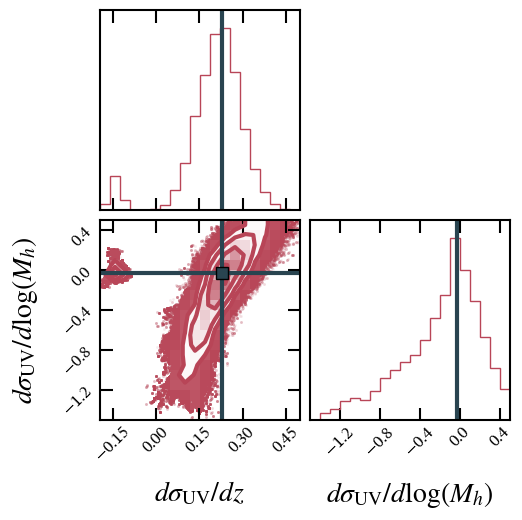

In [97]:
corner = eplots.make_corner(my_UVLF, true_vals = [0.23, -0.03], include_params = ['dsigdz', 'dsigdlogM'], backend_file = chain, truth_color = eplots.navy)

In [98]:
axes = corner.axes
axes[2].text(0.15, 2.7, r'$0.23$', color = eplots.navy)
axes[1].text(0.6, 0, r'$-0.03$', color = eplots.navy)

Text(0.6, 0, '$-0.03$')

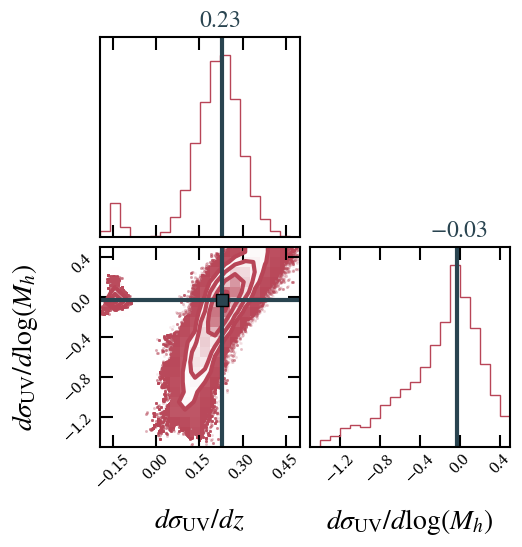

In [99]:
corner

In [100]:
corner.savefig('/Users/eb35267/Desktop/figures/Qual_26/corner.png', dpi = 200)

# UVLF for different models

working
working
working
working
working
working
working
working
working
working
working
working
working
working
working
working
working
working
working
working


/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:222: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)


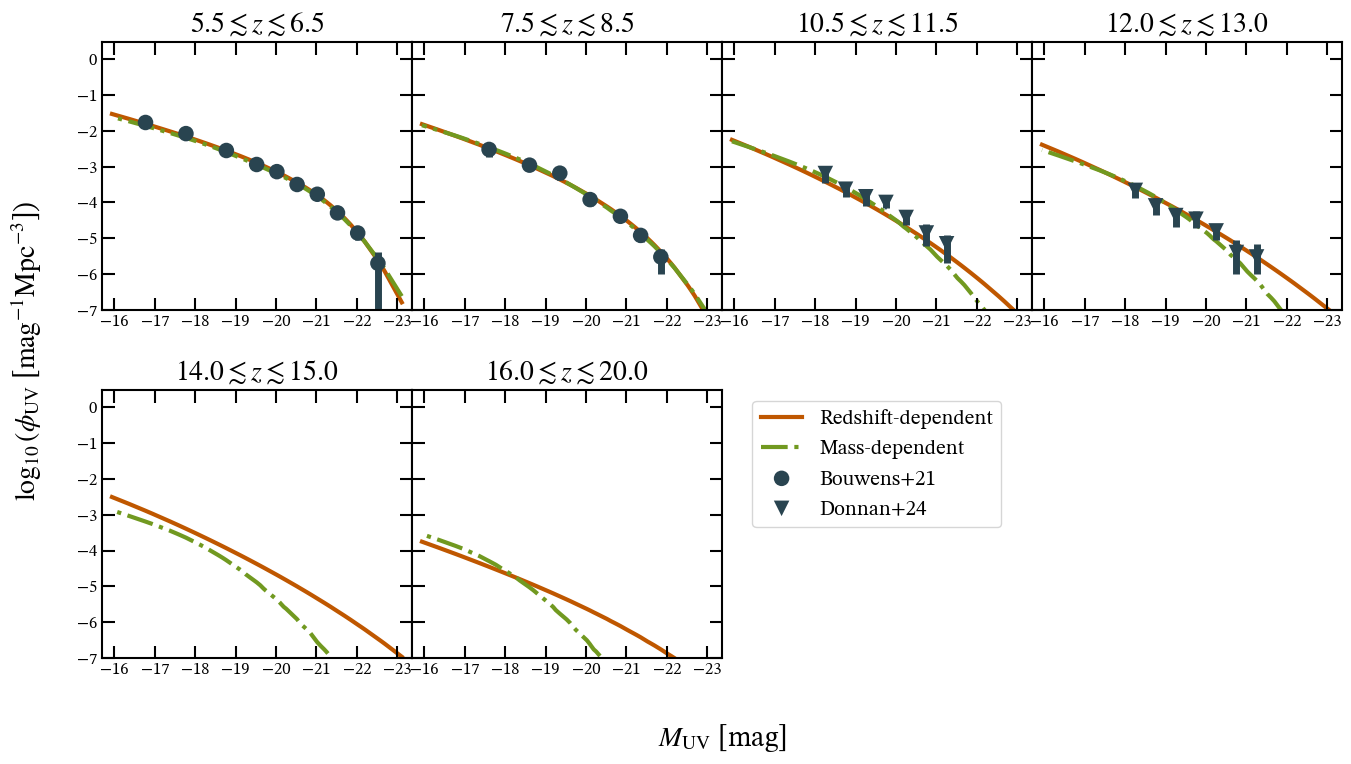

In [170]:
ev_fig = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain= False, comparison_fits = [no_m_ev, no_z_ev], comparison_labels = ['Redshift-dependent', 'Mass-dependent']
                                                                                                                                       , ncols = 4,
                                                                                                                                       z_plot = [6, 8, 11, 12.5, 14.5, 18],
                                                                                                                                       z_errs = [0.5, 0.5, 0.5, 0.5, 0.5, 2],
                                                                                                                                       show_chi2 = False)

In [152]:
ev_fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/extended_evolution.png', dpi = 200)

# Fiducial vs. piecewise

In [154]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24', r'Donnan+24 ultra high-$z$']
sorted_data = edata.get_sorted(file_names, data_labels)

In [2]:
params = eMCMC.build_param_data({})
UVLF_piecewise = eMCMC.UVLF(sorted_data, params)

NameError: name 'eMCMC' is not defined

In [156]:
no_m_ev_chunked = [0.49, -0.02, -1.49, 0.22, 11.76, -0.04, -1.34, -0.12, 0.53, 0.24, 0, 0.67]

chunked = [0.51, -0.02, 11.74, -0.04, -1.33, -0.12, [0.64, 0.67, 0.65, 0.69, 0.6, 0.69, 1.05, 1.46, 1.56], 0, 0, 0.3]

In [157]:
lowers = np.array([0.04, 0.03, 0.05, 0.07, 0.1, 0.12, 0.1, 0.08, 0.08])
uppers = np.array([0.04, 0.03, 0.03, 0.04, 0.06, 0.07, 0.05, 0.05, 0.05])

yerr = np.vstack((lowers, uppers))

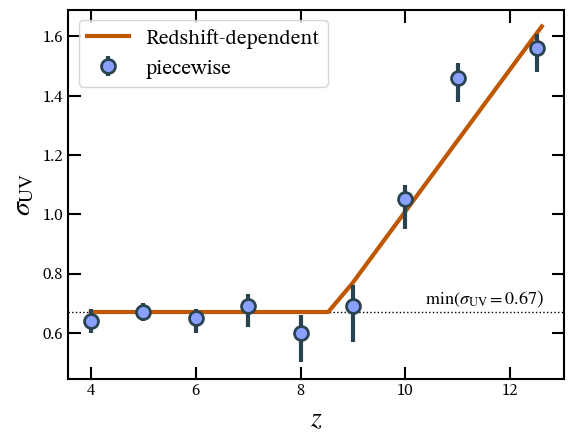

In [160]:
fig, ax = plt.subplots()
zs = np.linspace(4, 12.6, 20)
sig_lin = [UVLF_piecewise.time_evolution(no_m_ev_chunked, z)[-1][-1] for z in zs]
ax.plot(zs, sig_lin, color = eplots.orange, label = 'Redshift-dependent')
ax.errorbar(UVLF_piecewise.zs, chunked[-4], fmt = 'o', color = eplots.periwinkle, yerr = yerr, markersize = 10, ecolor = eplots.navy, 
            label = f'piecewise', markeredgecolor = eplots.navy, markeredgewidth = 2)

ax.axhline(0.67, zorder = 0, ls = 'dotted', color = 'black', lw = 1)
ax.text(11.5, 0.7, r'$\min(\sigma_{\rm{UV}} = 0.67$)', size = 13, ha = 'center')

ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel(r'$z$')
ax.legend()

In [161]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/fiducial_vs_piecewise.png', dpi = 200)

# Extend to higher $z$

In [54]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt', 
             '/Users/eb35267/Desktop/code/home/data/Donnan24_high_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Kokorev+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Weibel+25_upper_limits.txt']
data_labels = ['Bouwens+21', 'Donnan+24','Kokorev+25', 'Weibel+25']
include = [True, False, False, False, False]
sorted_data = edata.get_sorted(file_names, data_labels, include_in_likelihood = include)

In [55]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz': {'fit': False, 'value': 0.22}})
UVLF_extended = eMCMC.UVLF(sorted_data, params)

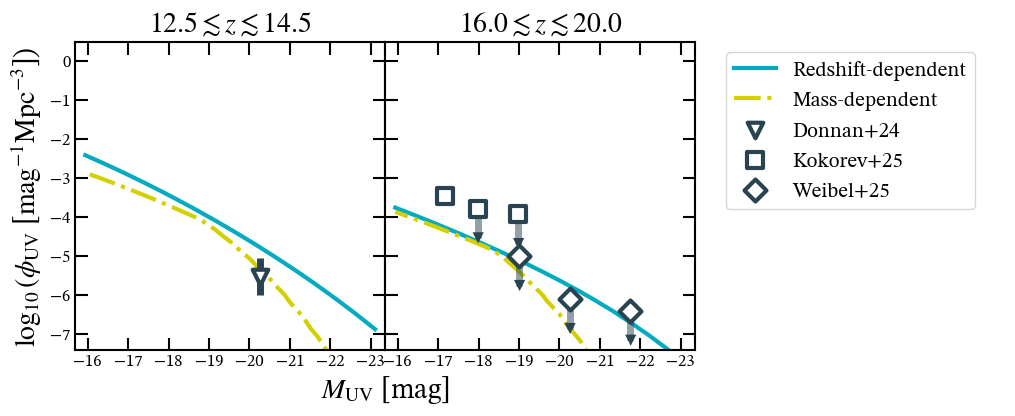

In [62]:
z_plot = [13.5, 18]
z_errs = [1, 2]
ext_ev = eplots.evolving_UVLF_fit(UVLF_extended, plot_from_chain = False, comparison_fits = [no_m_ev, no_z_ev], 
                               comparison_labels = ['Redshift-dependent', 'Mass-dependent'], z_plot = z_plot, z_errs = z_errs, show_chi2 = False, ncols = 3)

In [33]:
ext_ev.savefig('/Users/eb35267/Desktop/figures/Qual_26/extended_evolution.png', dpi = 200)

# Bias figure

In [ ]:
z_plot = [14.5, 18]
z_errs = [0.5, 2]

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


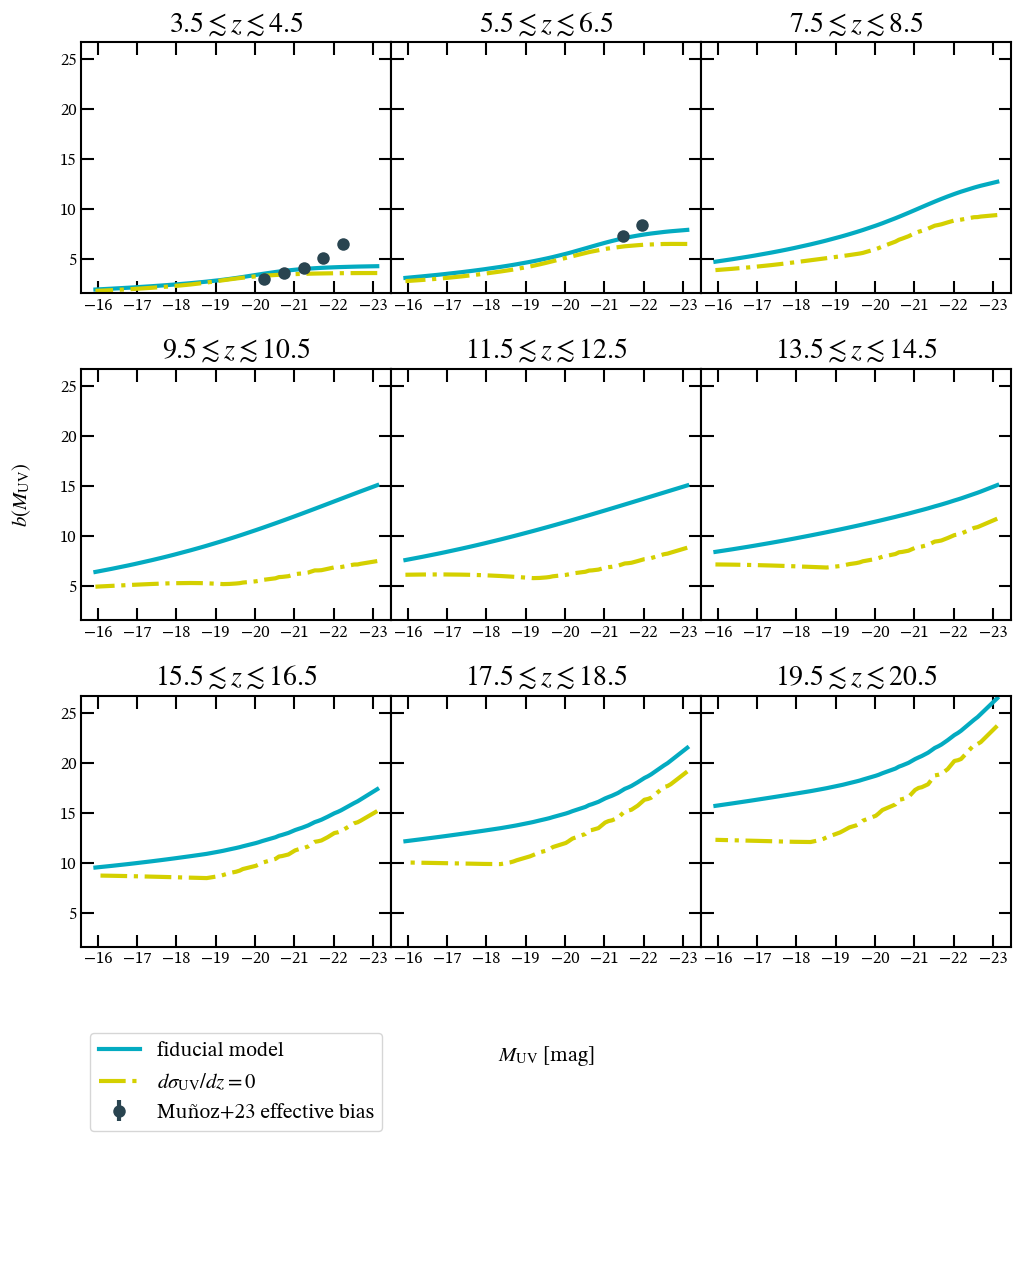

In [61]:
bias_fig = eplots.bias(UVLF_extended, compare_fits = [no_m_ev, no_z_ev], fit_labels = [r'fiducial model', r'$d\sigma_{\rm{UV}}/dz = 0$'], 
                       z_plot = np.arange(4, 22, 2))

# SFE

red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff
gold: #e8bf0f


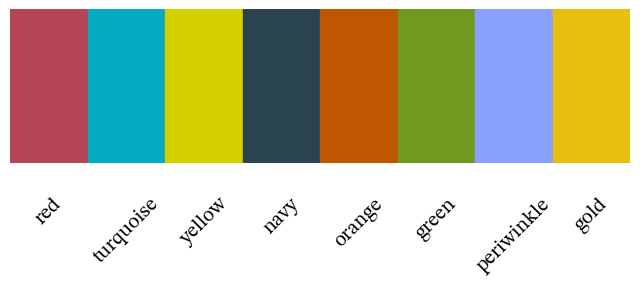

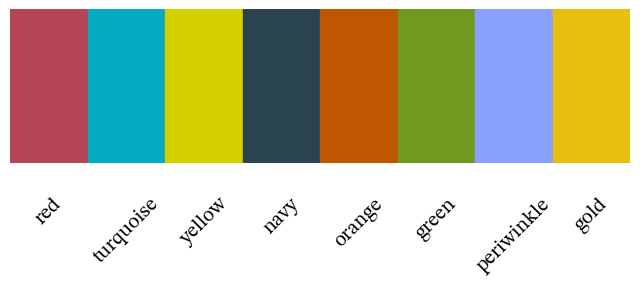

In [107]:
eplots.plot_colors()

In [114]:
importlib.reload(eplots)

/Users/eb35267/Desktop/code/home/escripts/eplots.py:624: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'$z \simeq {z}$')


<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

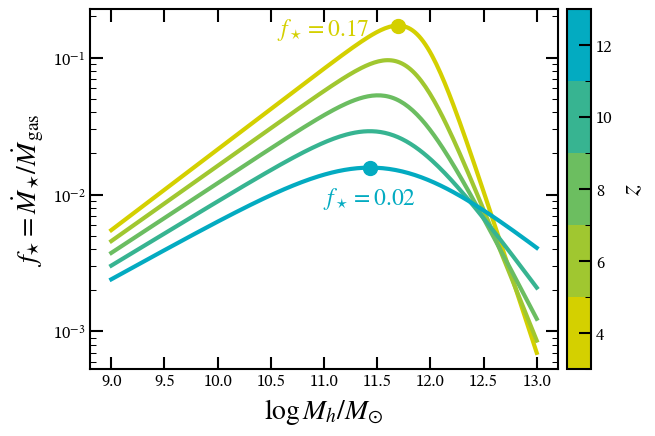

In [115]:
sfe_fig, ax= eplots.sfe_shape_diff_z(my_UVLF, best_fit, id_max = True, zs = np.arange(4, 12.5, 2))

In [116]:
sfe_fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/sfe.png', dpi = 200)

# Some illustrative plots can be found in the Committee25 notebook

In [203]:
from astropy import units as u
from astropy import constants as c

In [206]:
r_sc = (2*c.G*c.M_earth/c.c**2).to(u.pc)

In [210]:
r_sc = (2*c.G*1e10*c.M_sun/c.c**2).to(u.cm)

In [211]:
r_sc

<Quantity 2.95325008e+15 cm>